In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')


In [30]:
train = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\Food-Demand\train.csv')
fullfill = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\Food-Demand\fulfilment_center_info.csv')
meal = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\Food-Demand\meal_info.csv')
test = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\Food-Demand\test.csv')

In [31]:
train 

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40
...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68
456544,1062036,145,61,2304,482.09,482.09,0,0,42
456545,1110849,145,61,2664,237.68,321.07,0,0,501
456546,1147725,145,61,2569,243.50,313.34,0,0,729


In [32]:
meal.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [33]:
fullfill.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [34]:
df = pd.merge(train, fullfill, on='center_id')
df

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5


In [35]:
df = pd.merge(df, meal, on='meal_id')
df

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian


In [36]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine                456548 non-nu

(456548, 15)

In [37]:
df.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000


In [38]:
df.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

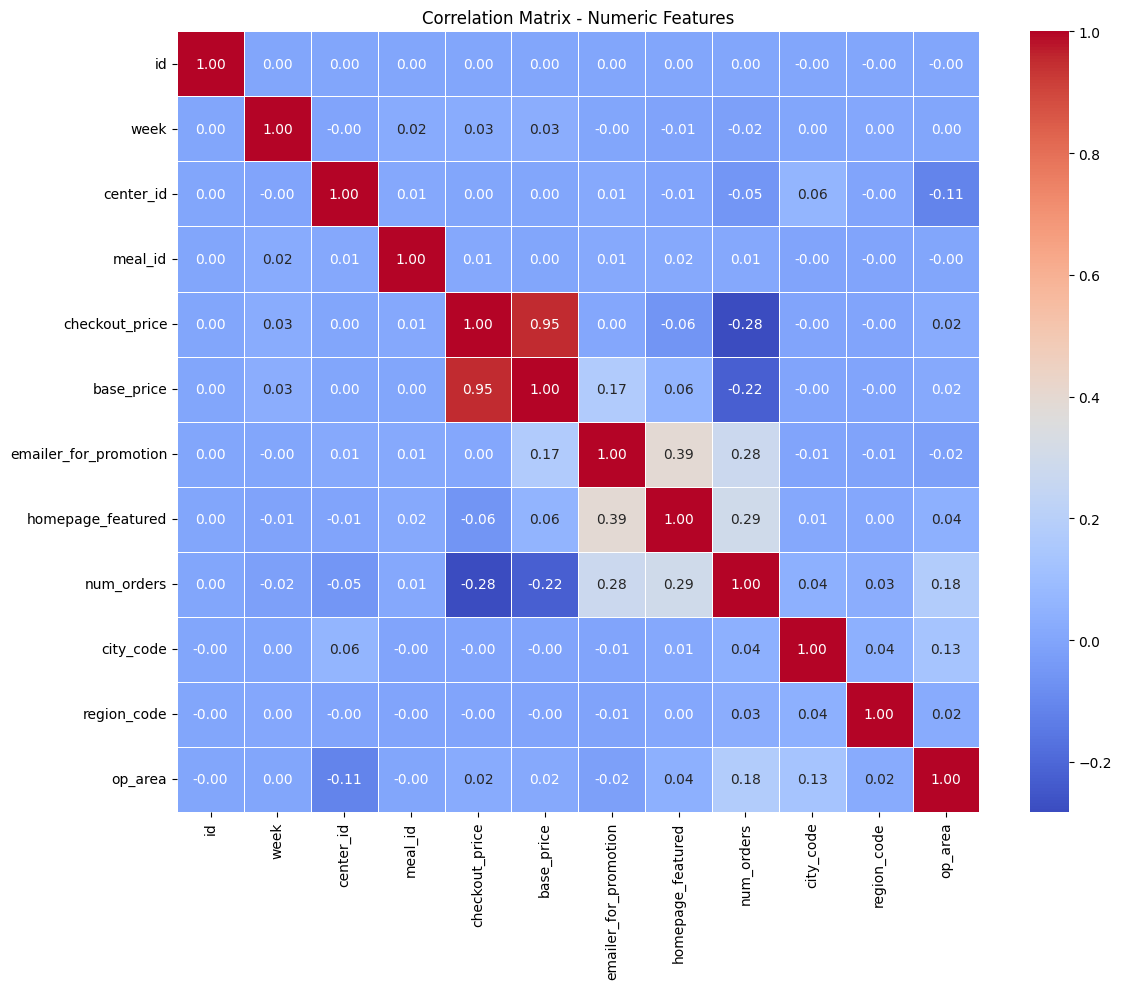

In [39]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

In [40]:
lb_enc = LabelEncoder()
df["make_Cent_type"] = lb_enc.fit_transform(df["center_type"])
df[["center_type", "make_Cent_type"]].head(10)

,center_type,make_Cent_type
0,TYPE_C,2
1,TYPE_C,2
2,TYPE_C,2
3,TYPE_C,2
4,TYPE_C,2
5,TYPE_C,2
6,TYPE_C,2
7,TYPE_C,2
8,TYPE_C,2
9,TYPE_C,2


In [41]:
df["make_category"] = lb_enc.fit_transform(df["category"])
df[["category", "make_category"]].head(10)

,category,make_category
0,Beverages,0
1,Beverages,0
2,Beverages,0
3,Beverages,0
4,Beverages,0
5,Beverages,0
6,Beverages,0
7,Beverages,0
8,Beverages,0
9,Beverages,0


In [42]:
df["make_cuisine"] = lb_enc.fit_transform(df["cuisine"])
df[["cuisine", "make_cuisine"]].head(10)

,cuisine,make_cuisine
0,Thai,3
1,Thai,3
2,Thai,3
3,Indian,1
4,Indian,1
5,Indian,1
6,Italian,2
7,Italian,2
8,Italian,2
9,Continental,0


In [43]:
cp_df = df.drop(columns=["center_type", "category", "cuisine"])
cp_df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,make_Cent_type,make_category,make_cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,2.0,2,0,3
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,2.0,2,0,3
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,2.0,2,0,3
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,2.0,2,0,1
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,2.0,2,0,1


In [44]:
X = cp_df.drop('num_orders', axis=1)
y = cp_df['num_orders']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

MODEL 1: LINEAR REGRESSION

Metrics Linear Regression:
MSE  : 114819.2736
RMSE : 338.8499
MAE  : 194.3255
MAPE : 2.2102
R² Score : 0.2473


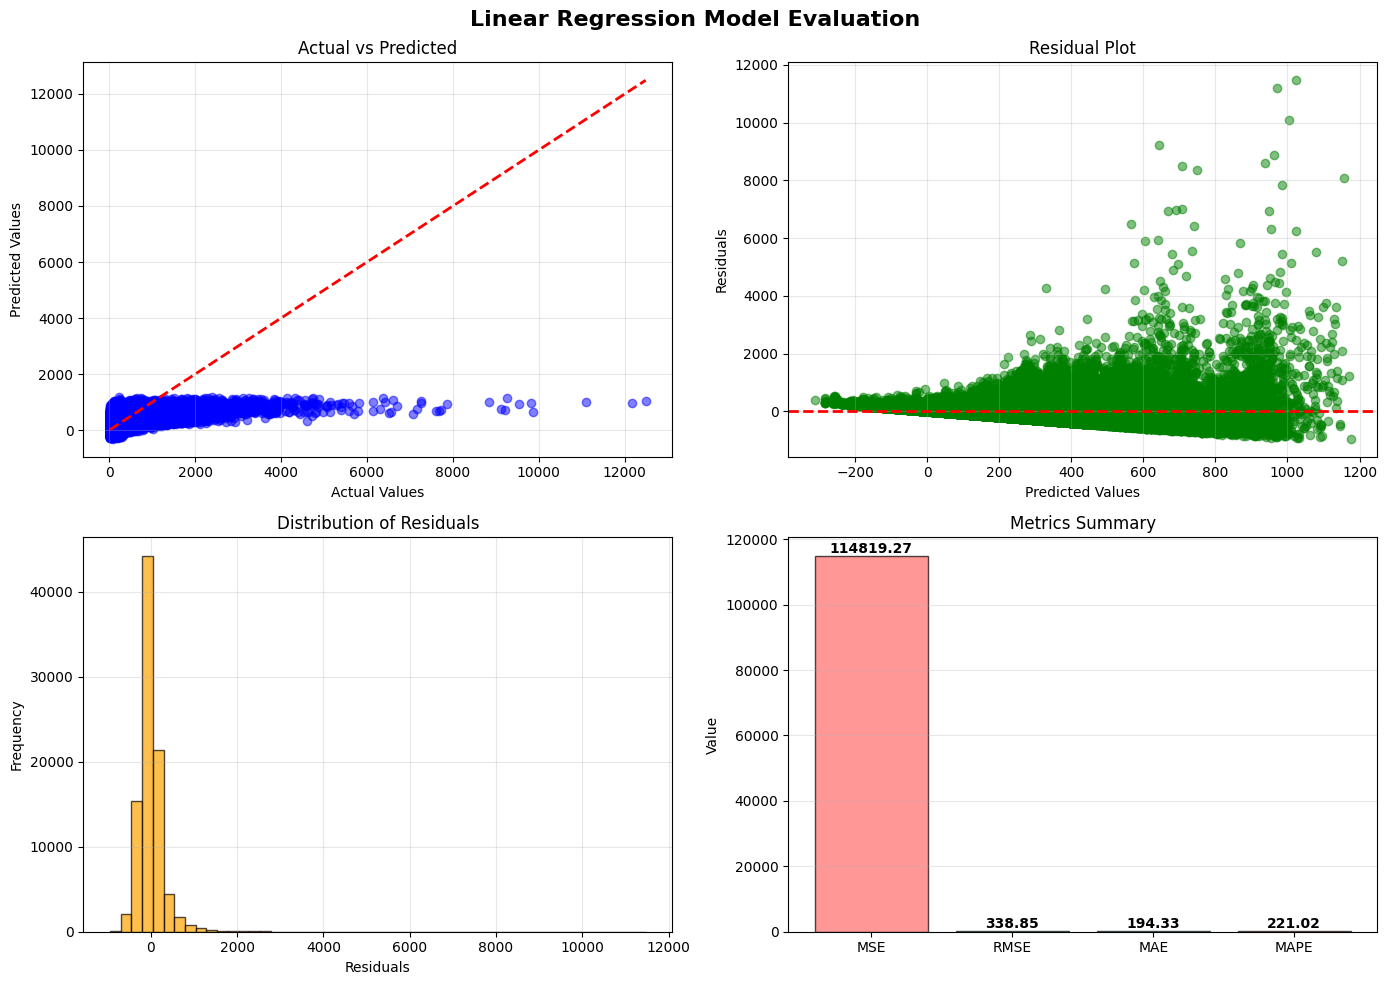

In [46]:
model_results = {}
# LINEAR REGRESSION MODEL

print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

# Hitung metrics untuk Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
r2_lr = lin_reg.score(X_test, y_test)

model_results['Linear Regression'] = {
    'MSE': mse_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'MAPE': mape_lr,
    'R2': r2_lr,
    'y_pred': y_pred_lr
}

print(f"\nMetrics Linear Regression:")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"MAPE : {mape_lr:.4f}")
print(f"R² Score : {r2_lr:.4f}")

# Visualisasi Linear Regression
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Model Evaluation', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals_lr = y_test - y_pred_lr
axes[0, 1].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
axes[1, 0].hist(residuals_lr, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Metrics Bar
metrics_names = ['MSE', 'RMSE', 'MAE', 'MAPE']
metrics_values = [mse_lr, rmse_lr, mae_lr, mape_lr*100]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Metrics Summary')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Tambah nilai di atas bar
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


MODEL 2: DECISION TREE REGRESSOR

Metrics Decision Tree Regressor:
MSE  : 36381.7611
RMSE : 190.7400
MAE  : 87.2699
MAPE : 0.5861
R² Score : 0.7615


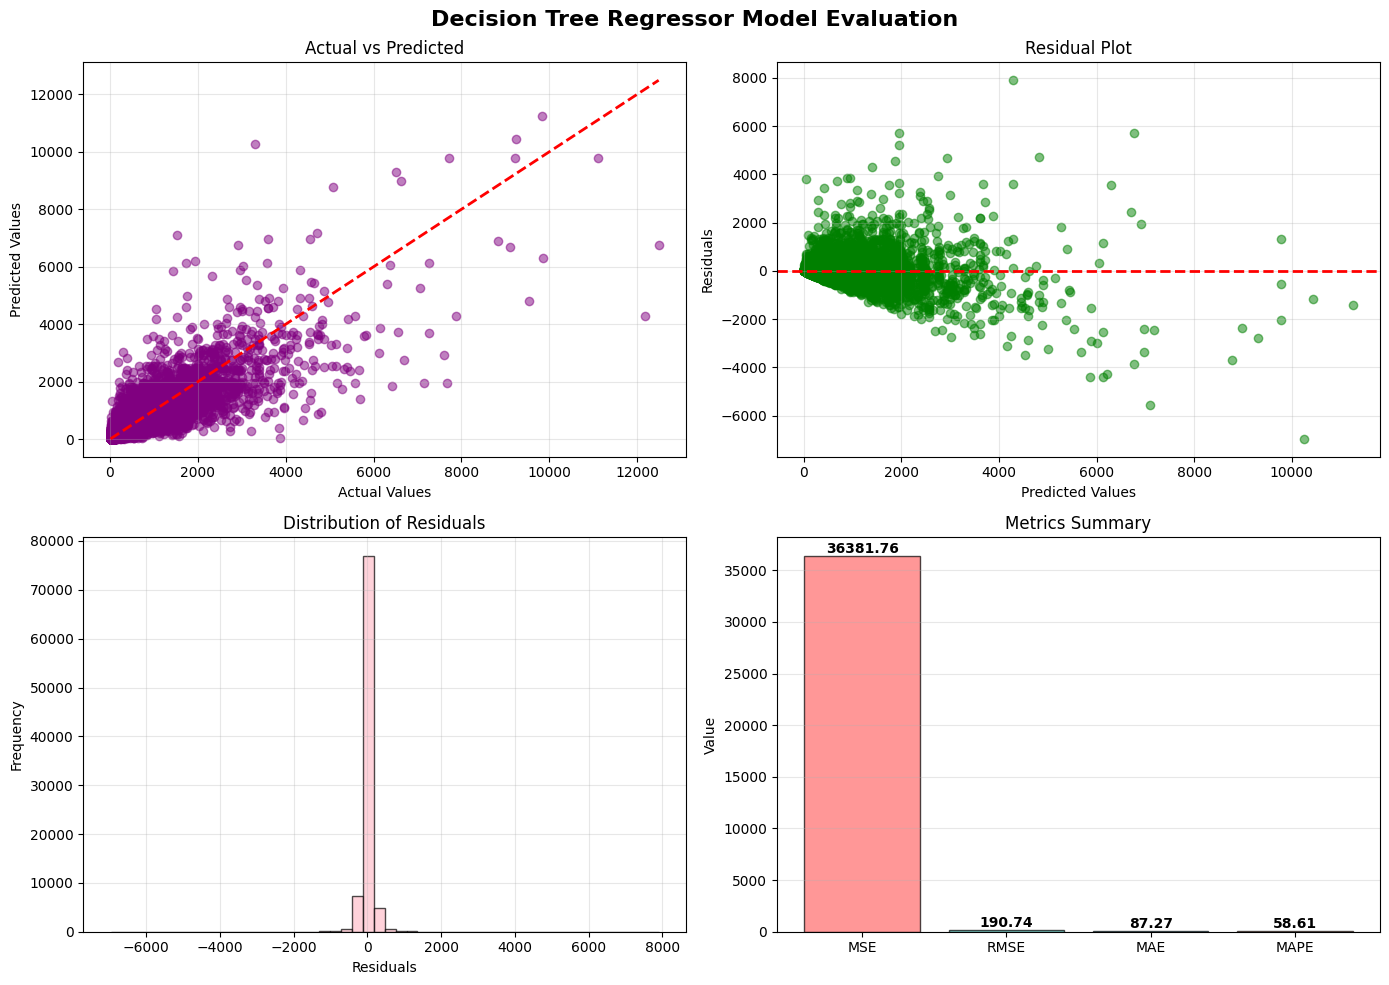

In [47]:
#DECISION TREE REGRESSOR MODEL

print("\n" + "=" * 60)
print("MODEL 2: DECISION TREE REGRESSOR")
print("=" * 60)

dt_reg = DecisionTreeRegressor(random_state=42, max_depth=15)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

# Hitung metrics untuk Decision Tree
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)
r2_dt = dt_reg.score(X_test, y_test)

model_results['Decision Tree'] = {
    'MSE': mse_dt,
    'RMSE': rmse_dt,
    'MAE': mae_dt,
    'MAPE': mape_dt,
    'R2': r2_dt,
    'y_pred': y_pred_dt
}

print(f"\nMetrics Decision Tree Regressor:")
print(f"MSE  : {mse_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"MAE  : {mae_dt:.4f}")
print(f"MAPE : {mape_dt:.4f}")
print(f"R² Score : {r2_dt:.4f}")

# Visualisasi Decision Tree
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Decision Tree Regressor Model Evaluation', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_dt, alpha=0.5, color='purple')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals_dt = y_test - y_pred_dt
axes[0, 1].scatter(y_pred_dt, residuals_dt, alpha=0.5, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
axes[1, 0].hist(residuals_dt, bins=50, color='pink', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Metrics Bar
metrics_names = ['MSE', 'RMSE', 'MAE', 'MAPE']
metrics_values = [mse_dt, rmse_dt, mae_dt, mape_dt*100]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Metrics Summary')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Tambah nilai di atas bar
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


MODEL 3: RANDOM FOREST REGRESSOR

Metrics Random Forest Regressor:
MSE  : 25897.8777
RMSE : 160.9282
MAE  : 78.4719
MAPE : 0.5697
R² Score : 0.8302


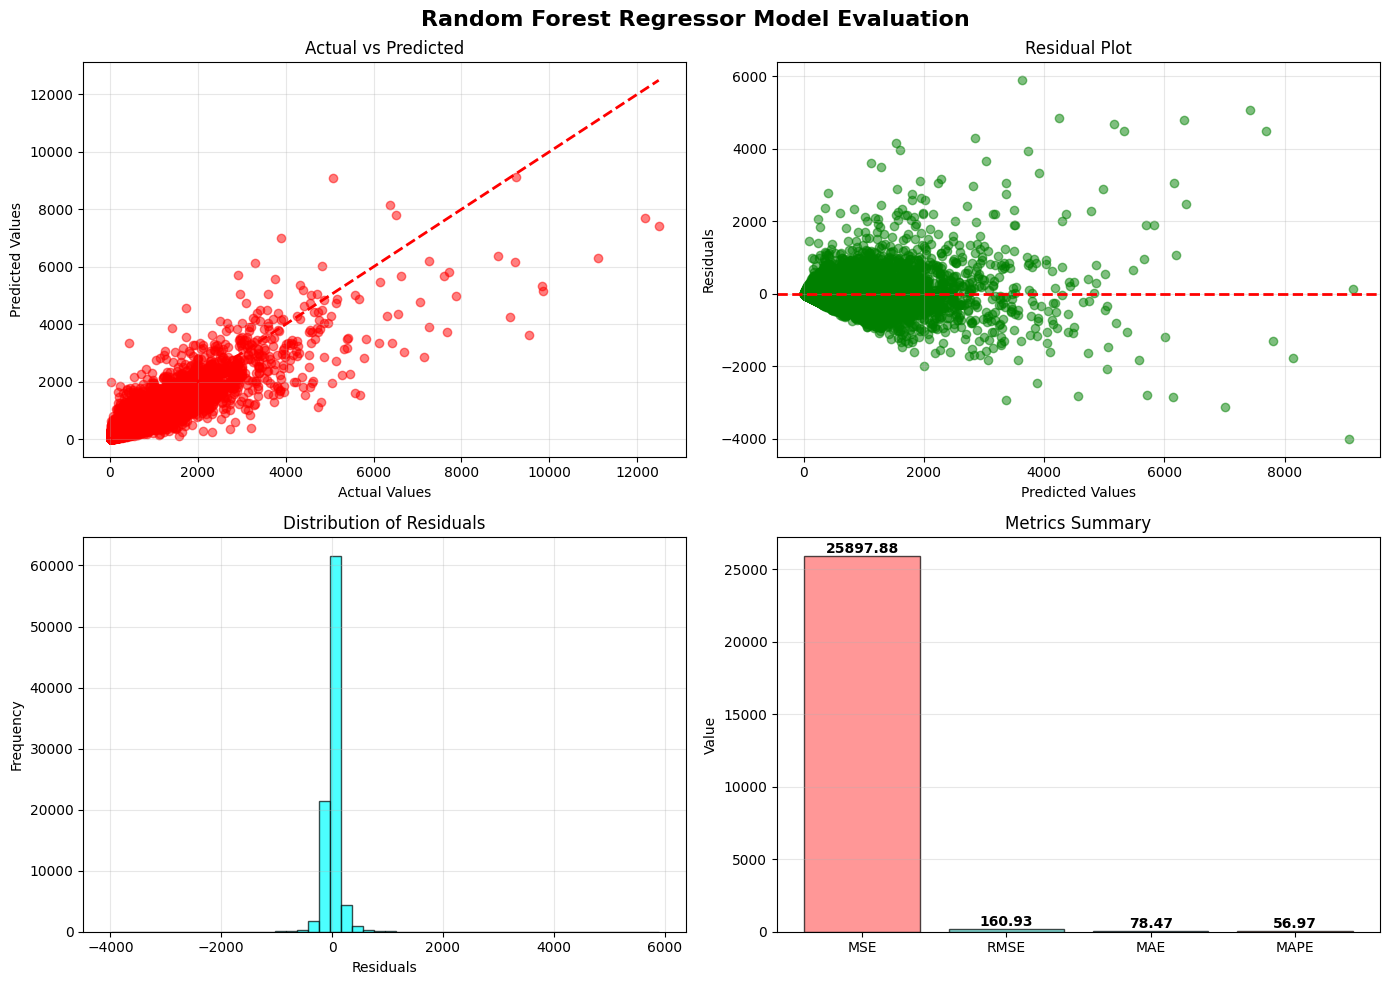

In [48]:
# RANDOM FOREST REGRESSOR MODEL

print("\n" + "=" * 60)
print("MODEL 3: RANDOM FOREST REGRESSOR")
print("=" * 60)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Hitung metrics untuk Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = rf_reg.score(X_test, y_test)

model_results['Random Forest'] = {
    'MSE': mse_rf,
    'RMSE': rmse_rf,
    'MAE': mae_rf,
    'MAPE': mape_rf,
    'R2': r2_rf,
    'y_pred': y_pred_rf
}

print(f"\nMetrics Random Forest Regressor:")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"MAPE : {mape_rf:.4f}")
print(f"R² Score : {r2_rf:.4f}")

# Visualisasi Random Forest
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest Regressor Model Evaluation', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.5, color='red')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals_rf = y_test - y_pred_rf
axes[0, 1].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
axes[1, 0].hist(residuals_rf, bins=50, color='cyan', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Metrics Bar
metrics_names = ['MSE', 'RMSE', 'MAE', 'MAPE']
metrics_values = [mse_rf, rmse_rf, mae_rf, mape_rf*100]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Metrics Summary')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Tambah nilai di atas bar
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


MODEL COMPARISON

                             MSE        RMSE         MAE      MAPE        R2
Linear Regression  114819.273649  338.849928  194.325488   2.21021  0.247252
Decision Tree       36381.761134  190.740035   87.269903  0.586062  0.761483
Random Forest       25897.877675  160.928176   78.471892  0.569696  0.830215


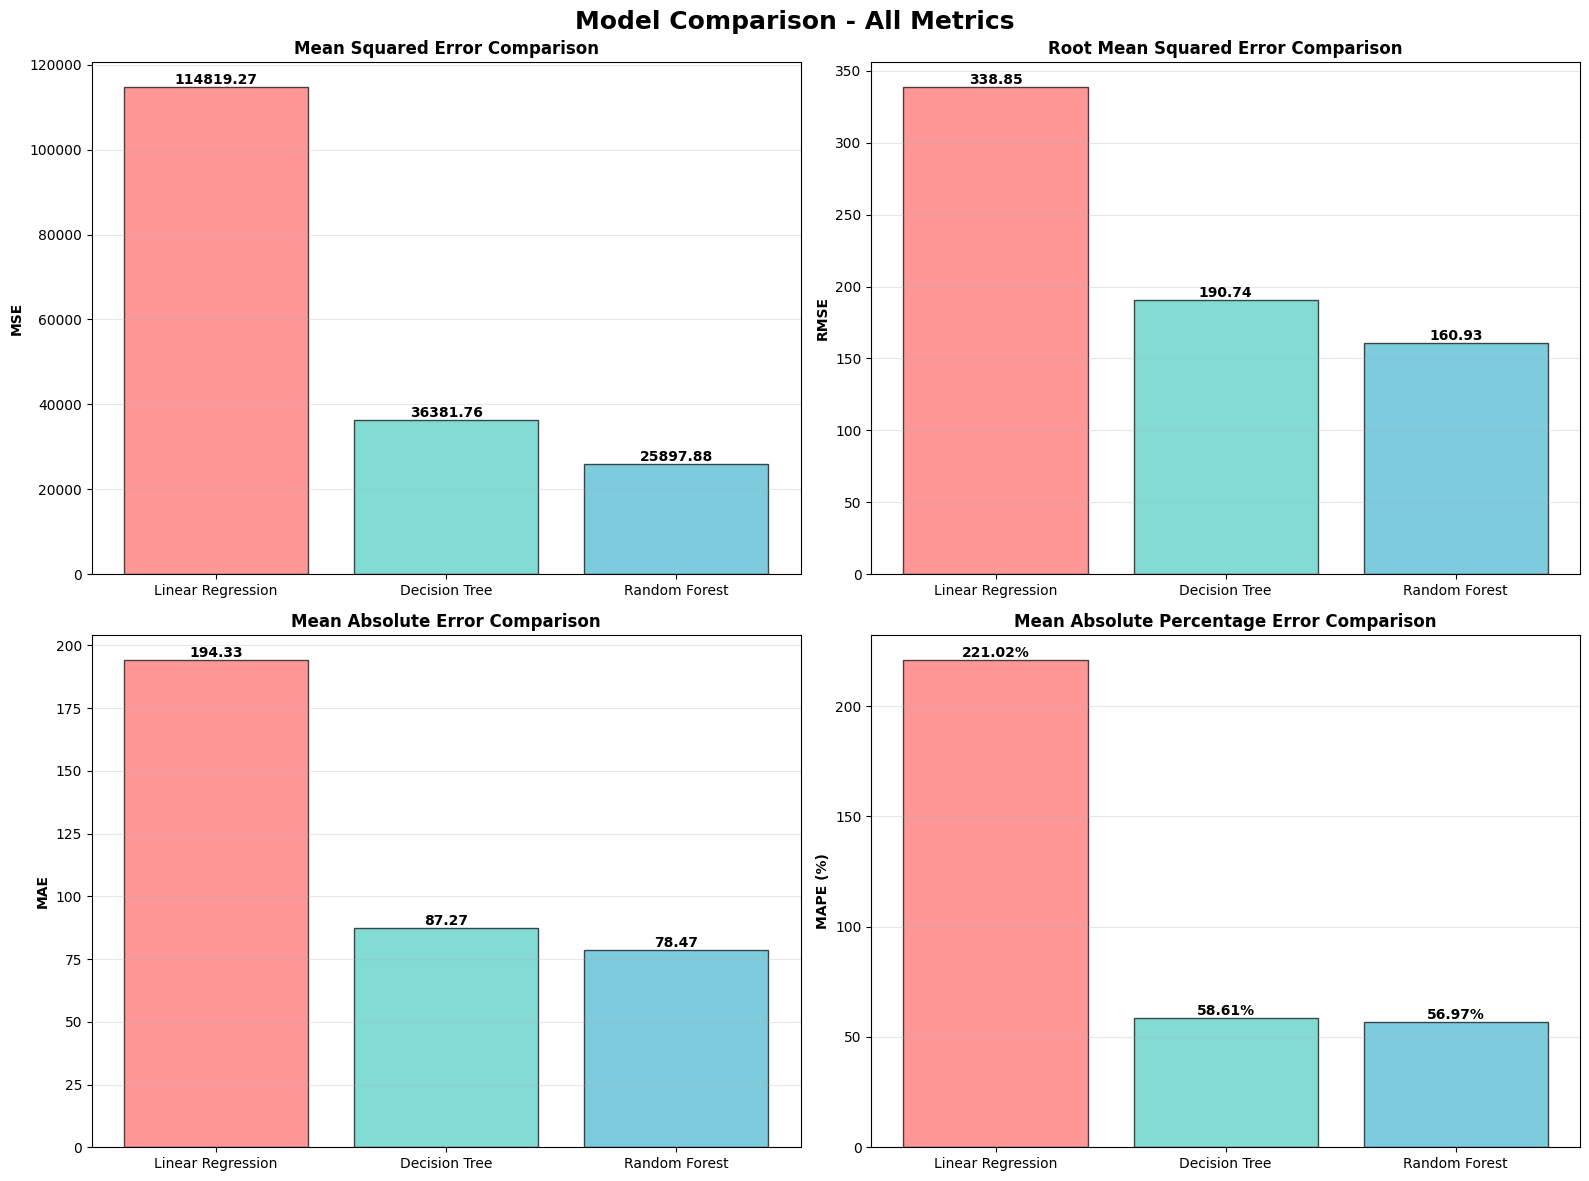


FEATURE IMPORTANCE - RANDOM FOREST

                  Feature  Importance
4          checkout_price    0.217962
12          make_category    0.151062
10                op_area    0.106806
7       homepage_featured    0.097162
5              base_price    0.074898
13           make_cuisine    0.065122
3                 meal_id    0.062006
1                    week    0.057141
2               center_id    0.051599
6   emailer_for_promotion    0.042124
8               city_code    0.023985
9             region_code    0.019892
0                      id    0.016782
11         make_Cent_type    0.013458


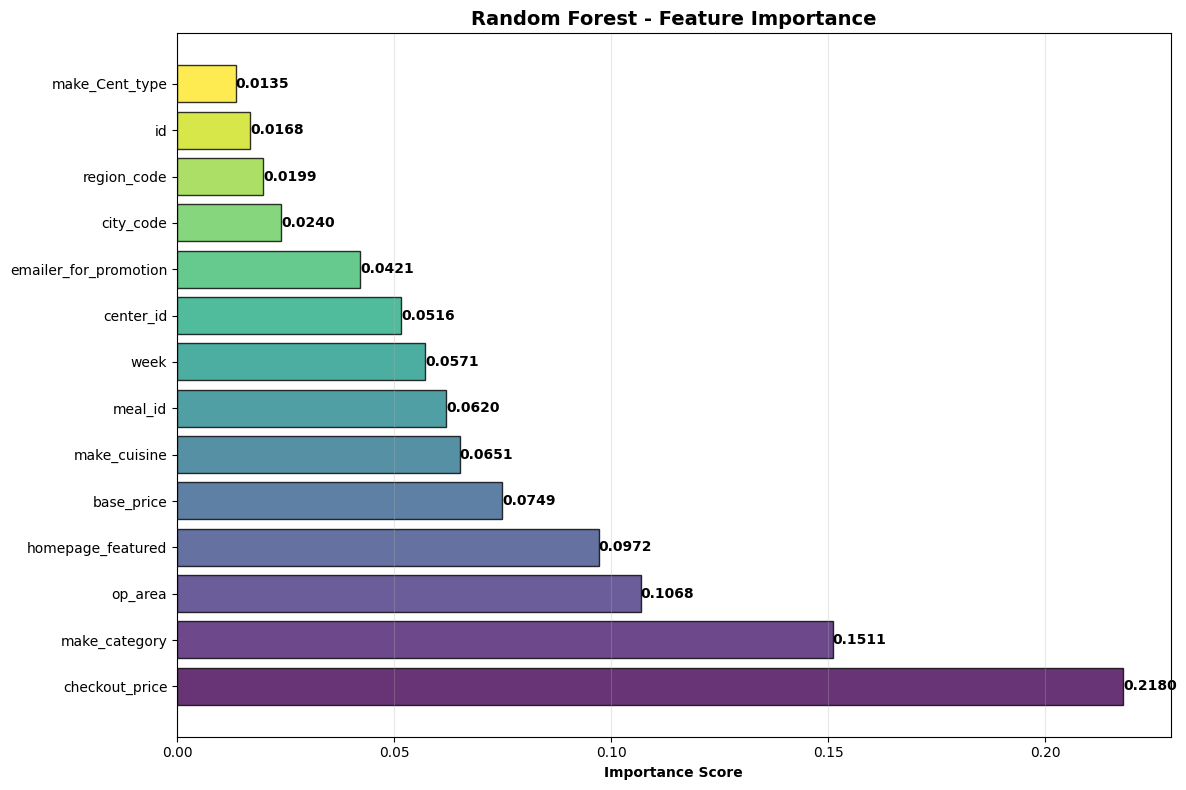

In [50]:
# MODEL COMPARISON

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Buat DataFrame hasil perbandingan
comparison_df = pd.DataFrame(model_results).T
comparison_df = comparison_df.drop('y_pred', axis=1)
print("\n" + comparison_df.to_string())

# Visualisasi Perbandingan Model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison - All Metrics', fontsize=18, fontweight='bold')

# Plot 1: MSE Comparison
models = list(model_results.keys())
mse_values = [model_results[m]['MSE'] for m in models]
colors_mse = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars1 = axes[0, 0].bar(models, mse_values, color=colors_mse, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('MSE', fontweight='bold')
axes[0, 0].set_title('Mean Squared Error Comparison', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: RMSE Comparison
rmse_values = [model_results[m]['RMSE'] for m in models]
bars2 = axes[0, 1].bar(models, rmse_values, color=colors_mse, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('RMSE', fontweight='bold')
axes[0, 1].set_title('Root Mean Squared Error Comparison', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: MAE Comparison
mae_values = [model_results[m]['MAE'] for m in models]
bars3 = axes[1, 0].bar(models, mae_values, color=colors_mse, edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('MAE', fontweight='bold')
axes[1, 0].set_title('Mean Absolute Error Comparison', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: MAPE Comparison
mape_values = [model_results[m]['MAPE']*100 for m in models]  # Convert to percentage
bars4 = axes[1, 1].bar(models, mape_values, color=colors_mse, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('MAPE (%)', fontweight='bold')
axes[1, 1].set_title('Mean Absolute Percentage Error Comparison', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar in bars4:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE - Random Forest

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + feature_importance.to_string())

# Visualisasi Feature Importance
fig, ax = plt.subplots(figsize=(12, 8))
colors_importance = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors_importance, edgecolor='black', alpha=0.8)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Tambah nilai di samping bar
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()